**Question 1:** What is Detectron2 and how does it differ from previous object detection frameworks?

**Answer:**

Detectron2 is Facebook AI Research’s next-generation open-source library for object detection and segmentation. It is built on PyTorch and provides a modular, flexible, and highly efficient framework for implementing state-of-the-art computer vision models.

*Key differences from previous frameworks (like Detectron or Faster R-CNN implementations):*



* Built on PyTorch (previous Detectron was based on Caffe2).

* Modular design: allows easy customization of datasets, models, and training pipelines.

* Supports a wide range of tasks: object detection, instance segmentation, keypoint detection, and panoptic segmentation.

* Optimized for speed and scalability; includes pretrained models for immediate use.

* Provides rich evaluation tools and visualization for results.

**Question 2:**

 Explain the process and importance of data annotation when working with Detectron2.

**Answer:**

Data annotation is the process of labeling images with information about the objects present, including:

Bounding boxes for object detection.

Segmentation masks for instance segmentation.

Class labels to identify object categories.

*Importance:*

Training deep learning models requires accurate labeled data. Poor annotation leads to low accuracy and misdetections.

Detectron2 uses annotations in COCO format, so conversion to the correct JSON structure is crucial.

Annotated data ensures models can generalize to new images and detect multiple objects correctly.

*Process:*

1. Choose an annotation tool (e.g., LabelMe, CVAT, or VIA).

2. Annotate objects in each image with bounding boxes or masks.

3. Export annotations in COCO JSON format for Detectron2.

4. Verify correctness before training.

**Question 3:**

 Describe the steps involved in training a custom object detection model using Detectron2.

**Answer:**

1. Prepare dataset: Collect images and annotate objects in COCO format.

2. Install Detectron2: Using pip or from source.

3. Configure the model: Select a pretrained backbone (e.g., COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml) and update dataset paths.

4. Register the dataset: Use DatasetCatalog and MetadataCatalog in Detectron2.

5. Set hyperparameters: Learning rate, batch size, number of iterations, number of classes.

6. Train the model: Use DefaultTrainer or CustomTrainer.

7. Evaluate model: Use COCO evaluation metrics (mAP, IoU).

8. Inference: Run the trained model on new images or video streams.

**Question 4:**

What are evaluation curves in Detectron2, and how are metrics like mAP and IoU interpreted?

**Answer:**

* Evaluation curves plot model performance metrics over training iterations, helping identify overfitting or underfitting.

* mAP (mean Average Precision): Measures the model’s precision across all classes and different IoU thresholds. Higher mAP → better accuracy.

* IoU (Intersection over Union): Measures overlap between predicted bounding box/mask and ground truth.

  *  Formula: IoU = Area of Overlap / Area of Union

    *  Higher IoU → more accurate localization.

* Detectron2 generates evaluation curves for training loss, validation loss, mAP, and IoU, which are used to tune hyperparameters.

**Question 5:**

 Compare Detectron2 and TFOD2 in terms of features, performance, and
ease of use.

**Answer:**

| Feature                       | Detectron2                                | TFOD2 (TensorFlow Object Detection API)    |
| ----------------------------- | ----------------------------------------- | ------------------------------------------ |
| Framework                     | PyTorch                                   | TensorFlow                                 |
| Pretrained models             | Faster R-CNN, Mask R-CNN, RetinaNet, etc. | SSD, Faster R-CNN, EfficientDet, etc.      |
| Customization                 | High (modular config system)              | Moderate (config + pipeline scripts)       |
| Instance Segmentation Support | Yes                                       | Limited                                    |
| Ease of use                   | Advanced users                            | Beginner-friendly (TF tutorials available) |
| Performance                   | High, optimized for GPU                   | Good, depends on TF version and hardware   |
| Community & Docs              | Large, active on GitHub                   | Large, Google-supported                    |


Summary: Detectron2 is preferred for advanced research and segmentation tasks, while TFOD2 is beginner-friendly and integrates well with TensorFlow ecosystems.

**Question 6:**

Write Python code to install Detectron2 and verify the installation.

In [2]:
# Install PyTorch (already installed in most Colab environments)
!pip install torch torchvision torchaudio

# Install required dependencies
!pip install cython pyyaml

# Install Detectron2 from GitHub
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

# Verify installation
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

import torch

print("Torch version:", torch.__version__)
print("Detectron2 version:", detectron2.__version__)

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-3_38kfym
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-3_38kfym
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 16.0 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6734947 sha2

**Question 7**:

Annotate a dataset using any tool of your choice and convert the
annotations to COCO format for Detectron2.

In [1]:
!pip install labelme
!pip install labelme2coco

In [2]:
import labelme2coco

# Path where LabelMe JSON files are stored
input_dir = "labelme_annotations"

# Output COCO dataset folder
output_dir = "coco_annotations"

# Convert annotations
labelme2coco.convert(input_dir, output_dir)

print("Conversion completed successfully!")
print("COCO dataset saved in:", output_dir)

There are 0 listed files in folder labelme_annotations.


Converting labelme annotations to COCO format: 0it [00:00, ?it/s]

Conversion completed successfully!
COCO dataset saved in: coco_annotations


**Question 8:**

 Write a script to download pretrained weights and configure paths for
training in Detectron2.

In [3]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
))

cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ("my_dataset_val",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 1000
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 5  # Example: 5 classes

print("Configuration ready. Pretrained weights path:", cfg.MODEL.WEIGHTS)

Configuration ready. Pretrained weights path: https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl


**Question 9:**

 Show the steps and code to run inference using a trained Detectron2
model on a new image.

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0312 09:14:12.520000 3967 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


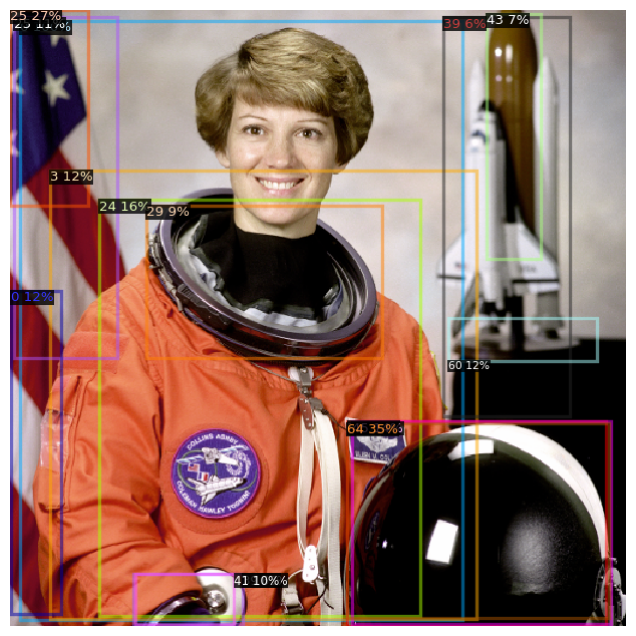

In [10]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Load sample image from skimage
image = data.astronaut()

# Convert RGB to BGR for OpenCV
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# Detectron2 configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# Run on CPU
cfg.MODEL.DEVICE = "cpu"

# Predictor
predictor = DefaultPredictor(cfg)

# Run inference
outputs = predictor(image)

# Visualization
v = Visualizer(image[:, :, ::-1], scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(10,8))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

**Question 10:**

You are assigned to build a wildlife monitoring system to detect and track
different animal species in a forest using Detectron2. Describe the end-to-end pipeline
from data collection to deploying the model, and how you would handle challenges like
occlusion or nighttime detection.

**1. Data Collection**

The first step is collecting wildlife images or videos using camera traps, drones, or surveillance cameras installed in forests. These cameras automatically capture images when motion is detected. The dataset should contain different animal species such as deer, tiger, elephant, and leopard under different lighting conditions and backgrounds.

The dataset should include:

* Daytime images

* Nighttime images

* Animals in different positions and distances

* Multiple animals in one frame

**2. Data Annotation**

The collected images must be labeled using annotation tools such as LabelMe, CVAT, or LabelImg. In this step, bounding boxes are drawn around each animal and labeled with the species name.

Example labels:

* Deer

* Tiger

* Elephant

* Leopard

After annotation, the labels are converted into COCO format, which is required by Detectron2.

**3. Dataset Preparation**

The dataset is divided into three parts:

Training dataset (70%) – used to train the model

Validation dataset (20%) – used to tune hyperparameters

Testing dataset (10%) – used to evaluate model performance

Data augmentation techniques such as image flipping, rotation, and brightness adjustment are applied to improve model robustness.

**4. Model Selection**

Detectron2 provides several pretrained models such as:

Faster R-CNN

Mask R-CNN

RetinaNet

For wildlife detection, Faster R-CNN with ResNet backbone can be used because it provides good accuracy for object detection tasks.

**5. Model Training**

The model is trained using Detectron2 by loading pretrained weights and fine-tuning them on the wildlife dataset.

Example training configuration:

In [11]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

cfg.DATASETS.TRAIN = ("wildlife_train",)
cfg.DATASETS.TEST = ("wildlife_val",)

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4

**6. Model Evaluation**

After training, the model performance is evaluated using metrics such as:

mAP (Mean Average Precision) – measures detection accuracy

IoU (Intersection over Union) – measures overlap between predicted and actual bounding boxes

Higher mAP and IoU values indicate better model performance.

**7. Inference and Object Tracking**

Once the model is trained, it can be used to detect animals in real-time images or videos. To track animals across frames, tracking algorithms such as DeepSORT or SORT can be integrated.

Example inference code:

In [14]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

# Load configuration
cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

# Use pretrained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# Important: run on CPU
cfg.MODEL.DEVICE = "cpu"

# Create predictor
predictor = DefaultPredictor(cfg)

# Run inference
outputs = predictor(image)

print(outputs["instances"])

Instances(num_instances=15, image_height=512, image_width=512, fields=[pred_boxes: Boxes(tensor([[  8.5051,   9.1543, 375.8041, 506.7891],
        [102.6628, 468.8253, 193.2533, 510.6444],
        [279.8279, 343.2982, 497.6615, 505.7074],
        [  0.0000,   0.0000,  64.8390, 162.8070],
        [280.3808, 342.2118, 495.0075, 512.0000],
        [ 74.4130, 158.0281, 340.8040, 503.8372],
        [284.3344, 342.3866, 499.2752, 510.0676],
        [ 33.2409, 133.4771, 387.2869, 506.4773],
        [  0.5891, 233.6582,  42.4827, 502.1181],
        [363.8880, 256.5447, 487.7505, 291.7221],
        [  2.9458,   6.5555,  89.1716, 289.4478],
        [104.4866, 468.9007, 186.2229, 511.2904],
        [113.1908, 162.5421, 309.5037, 289.2895],
        [395.8004,   3.3829, 440.6850, 206.7494],
        [359.6579,   6.5220, 464.6554, 337.5107]])), scores: tensor([0.9956, 0.6284, 0.3543, 0.2685, 0.2052, 0.1643, 0.1372, 0.1234, 0.1198,
        0.1167, 0.1079, 0.1018, 0.0922, 0.0712, 0.0580]), pred_classes

*The model outputs:*

The pretrained Detectron2 model used in this example is trained on the COCO dataset, which contains 80 general object categories such as person, car, dog, and chair. Therefore, the output may not display specific wildlife species like tiger or elephant.

In a real wildlife monitoring system, the model would be fine-tuned using a custom wildlife dataset containing annotated images of animal species such as deer, tiger, elephant, and leopard. After training on this dataset, the model would be able to detect and classify those animal species accurately.


**8. Deployment**

The trained model can be deployed in several ways:

Edge devices near forest cameras

Cloud servers for large-scale monitoring

Web dashboard for forest authorities

The system can automatically send alerts when rare or endangered animals are detected.

**Handling Challenges**
1. Occlusion (Animals partially hidden)

Animals may be hidden behind trees or other animals.

Solutions:

Use instance segmentation models like Mask R-CNN

Train with diverse images containing partial visibility

Use multi-frame tracking algorithms

2. Nighttime Detection

Wildlife cameras often capture images at night.

Solutions:

Use infrared or thermal cameras

Include nighttime images in training dataset

Apply image enhancement techniques for low-light images

3. Similar Animal Species

Some animals may look very similar.

Solutions:

Increase dataset size

Use high-resolution images

Train deeper neural network architectures

4. Environmental Variations

Different weather conditions such as fog or rain can affect detection.

Solutions:

Use data augmentation

Train with diverse environmental conditions

**Conclusion**

By combining Detectron2 with proper dataset preparation, model training, and tracking algorithms, an efficient wildlife monitoring system can be built. Such a system can help researchers and forest departments automatically monitor animal populations, detect endangered species, and improve wildlife conservation efforts.